# Exploration 04 — classical models: accurate first (Track A), then quantum-comparable (Track B)

> **Exploratory** (CLAUDE.md, "Exploration"). **Inputs:** Z and R only (the headline-legal feature sets and the
> per-atom environments of notebook 02). **Data:** the nested training sets S_(s,N), tuned inside each one, and the
> development sets `dev` (familiar formulas) and `dev_unseen` (formulas absent from every training set). No test
> set is read.

**Part 4 of the classical analysis, rebuilt for exploration X2** (DECISIONS.md, 2026-10-06). X1 followed PLAN.md
literally (N ≤ 1000, 7,131 pool molecules, rotation-invariant global features, small fixed grids) and its best model
reached CV MAE 0.71 D. This notebook answers two questions, in this order:

1. **Track A — how accurate can a classical model get from Z and R?** Every choice is made for accuracy: training
   sets from 100 molecules up to the full 99,198-molecule pool; the richest legal features; a randomized
   hyperparameter search with early stopping for gradient boosting; and the **latent-charge model**, which predicts a
   charge per atom from its environment and outputs |Σ qᵢ cᵢ| (+ bond-directed atomic dipoles), with message passing
   along bonds. It is chosen among candidate architectures on an inner validation split of S_(0,10000).
2. **Track B — what should a quantum model be compared with?** The same pipeline scaled down to the quantum regime:
   N ≤ 1000 and k inputs (the reduction and k chosen in notebook 03). These are matched baselines for M4. **They
   are never the best classical can do**: every quantum result must be reported against Track A as well.

**Protocol.** Each model tunes inside its training set only: 5-fold CV for N ≤ 1000 (the same folds for every model,
the X1 protocol), an inner validation split above. Every fitted transform sits inside the model. Scores: MAE
(primary), RMSE, RMSE without the |μ| ≥ 9 D tail, R² and bias, in debye, on `dev` and `dev_unseen`. Finished runs are
cached per commit (`data/processed/cache/`), so a re-run at the same commit reproduces them without retraining.

Runtime from scratch: about three to four hours on a 4-core CPU, most of it the charge network and gradient boosting
on the full pool.

In [1]:
# Environment check: stops here, with setup instructions, unless this kernel is the project
# environment (README.md, "Setup"). Version differences from requirements.txt only warn.
try:
    from qm9dipole.provenance import check_environment
except ModuleNotFoundError as e:
    raise RuntimeError(
        "The qm9dipole package is not installed in this kernel's environment. Follow "
        "README.md (Setup), then select that environment as the notebook kernel."
    ) from e

print(check_environment())

environment OK: Python 3.12.14, 16 pinned packages checked, 0 differ; package and notebook are in the same checkout


In [2]:
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import FixedLocator, NullFormatter, NullLocator

from qm9dipole import REPO_ROOT
from qm9dipole.analysis import loglog_slope
from qm9dipole.data import PROCESSED_DIR, load_qm9_table
from qm9dipole.evaluate import dev_curve
from qm9dipole.explore import (development_ids, feature_sets, load_atoms, load_catalog, load_config, load_features,
                               load_preprocessing)
from qm9dipole.models import classical
from qm9dipole.models.fitters import ChargeFitter, MeanFitter, TabularFitter, XGBFitter
from qm9dipole.plots import INK_SECONDARY, MODEL_COLORS, MODEL_LABELS, MUTED, SERIES, SURFACE, use_style
from qm9dipole.provenance import config_hash, git_hash, save_result
from qm9dipole.splits import load_splits

use_style()
FIG_DIR = REPO_ROOT / "figures"
CFG = load_config()
TA, CC, TBC = CFG["track_a"], CFG["charge_model"], CFG["track_b"]
features = load_features()
catalog = load_catalog()
SETS = feature_sets(catalog)
PRE = load_preprocessing()
SC_A, SC_B = PRE["scaling"]["track_a"], PRE["scaling"]["track_b"]
TG_A, TG_B = PRE["target"]["track_a"], PRE["target"]["track_b"]
RED = (PRE["reduction"]["method"], int(PRE["reduction"]["k"]))
splits = load_splits()
y = features["mu"]
EVAL = {"dev": splits.dev, "dev_unseen": splits.dev_unseen}
SIZES = splits.sizes
FULL = SIZES[-1]
CACHE = PROCESSED_DIR / "cache" / "explore04" / git_hash(short=True)
print(f"from notebook 03: Track A scaling {SC_A}, target {TG_A}; Track B scaling {SC_B}, target {TG_B}; "
      f"reduction {RED[0]} to k = {RED[1]}")
print(f"training sizes {SIZES} × seeds {list(splits.train)}; evaluation: dev {len(splits.dev):,}, dev_unseen {len(splits.dev_unseen):,}")

start = time.perf_counter()
table = load_qm9_table()
atoms = load_atoms(table, development_ids(splits), catalog)
del table
print(f"per-atom features: {atoms.X.shape[1]} for {atoms.X.shape[0]:,} atoms of {atoms.n_molecules:,} molecules "
      f"({time.perf_counter() - start:.0f} s)")

LABELS, COLORS = MODEL_LABELS, MODEL_COLORS

from notebook 03: Track A scaling log_standard, target standard; Track B scaling yeo_johnson, target sqrt; reduction pls to k = 10
training sizes [100, 300, 1000, 3000, 10000, 30000, 99198] × seeds [0, 1, 2]; evaluation: dev 5,000, dev_unseen 4,183


per-atom features: 85 for 1,939,514 atoms of 108,381 molecules (87 s)


## 1. Choosing the latent-charge architecture

Eight candidates from `configs/explore.yaml`, from a linear charge model (each atom's charge a linear function of its
85 environment features: about a hundred parameters) to networks with two or three message-passing rounds along the
bonds and bond-directed atomic dipoles. Each trains on S_(0,10000) with early stopping on its own inner validation
split (10% of the training set). **The choice uses that inner validation MAE only**; the development-set columns are
shown for information.

In [3]:
def charge_params(name):
    p = {**CC["common"], **CC["candidates"][name]}
    p["hidden"] = tuple(p["hidden"])
    return p

SEL_N = CC["selection_n"]
selection, _ = dev_curve(lambda seed, n: {name: ChargeFitter(atoms, charge_params(name), seed) for name in CC["candidates"]},
                         {0: {SEL_N: splits.train[0][SEL_N]}}, EVAL, y, cache_dir=CACHE)
details = selection.drop_duplicates("model").set_index("model")["details"].map(json.loads)
sel = pd.DataFrame({
    "parameters": details.map(lambda d: d["n_parameters"]),
    "epochs (best)": details.map(lambda d: f"{d['epochs'][0]} ({d['best_epoch'][0]})"),
    "minutes": selection.drop_duplicates("model").set_index("model")["fit_seconds"] / 60,
    "inner validation MAE (D)": details.map(lambda d: d["inner_val_mae_D"][0]),
    "dev MAE (D)": selection[selection["eval_set"] == "dev"].set_index("model")["mae_D"],
    "dev_unseen MAE (D)": selection[selection["eval_set"] == "dev_unseen"].set_index("model")["mae_D"],
})
NET = sel["inner validation MAE (D)"].idxmin()
LIN = sel.loc[[c for c in CC["candidates"] if not CC["candidates"][c]["hidden"]], "inner validation MAE (D)"].idxmin()
display(sel.style.format({"minutes": "{:.1f}", "inner validation MAE (D)": "{:.3f}", "dev MAE (D)": "{:.3f}",
                          "dev_unseen MAE (D)": "{:.3f}"}).highlight_min(subset=["inner validation MAE (D)"], props="font-weight: bold")
        .set_caption(f"Latent-charge candidates on S_(0,{SEL_N})"))
print(f"chosen network: {NET}; chosen linear charge model: {LIN}")
_ = save_result(selection, "explore04_charge_selection", selection_n=SEL_N, chosen=NET, chosen_linear=LIN,
                label="exploratory; Z, R only; chosen by the inner validation split of S_(0,10000); dev scores for information")

seed 0  N=10000  linear           dev MAE 0.515 D  (10 s)


seed 0  N=10000  linear+dipoles   dev MAE 0.221 D  (23 s)


seed 0  N=10000  mlp              dev MAE 0.119 D  (69 s)


seed 0  N=10000  mp2              dev MAE 0.222 D  (181 s)


seed 0  N=10000  mp3              dev MAE 0.094 D  (326 s)


seed 0  N=10000  mp2-no-dipoles   dev MAE 0.245 D  (240 s)


seed 0  N=10000  mp3-narrow       dev MAE 0.101 D  (116 s)


seed 0  N=10000  mp2-mse          dev MAE 0.124 D  (204 s)


,parameters,epochs (best),minutes,inner validation MAE (D),dev MAE (D),dev_unseen MAE (D)
model,,,,,,
linear,90,122 (92),0.2,0.505,0.515,0.759
linear+dipoles,520,158 (148),0.4,0.228,0.221,0.369
mlp,19658,123 (93),1.1,0.116,0.119,0.187
mp2,85450,112 (82),3.0,0.191,0.222,0.345
mp3,118346,159 (129),5.4,0.092,0.094,0.155
mp2-no-dipoles,85125,157 (127),4.0,0.217,0.245,0.382
mp3-narrow,34826,101 (71),1.9,0.103,0.101,0.169
mp2-mse,85450,133 (103),3.4,0.130,0.124,0.193


chosen network: mp3; chosen linear charge model: linear+dipoles


## 2. Track A: learning curves up to the full training pool

Six models at every training size N = 100 … 99,198 and every seed: the mean baseline; ridge, RBF kernel ridge
(exact, so up to N = 10,000) and XGBoost (randomized search, 20 draws up to N = 10,000 and 10 above, early stopping)
on the 188 all_legal features; the chosen linear charge model; and the chosen charge network.

In [4]:
XA = features[SETS["all_legal"]]
P_NET, P_LIN = charge_params(NET), charge_params(LIN)

def make_track_a(seed, n):
    out = {"mean": MeanFitter()}
    est, grid = classical.build("ridge", seed, scaling=SC_A, target=TG_A, n_features=XA.shape[1])
    out["ridge"] = TabularFitter(XA, est, grid, seed)
    if n <= TA["krr_max_n"]:
        est, grid = classical.build("rbf_krr", seed, scaling=SC_A, target=TG_A, n_features=XA.shape[1])
        out["rbf_krr"] = TabularFitter(XA, est, grid, seed)
    n_iter = TA["xgb_iter"]["small"] if n <= TA["xgb_large_n"] else TA["xgb_iter"]["large"]
    out["xgb"] = XGBFitter(XA, seed, n_iter=n_iter, target=TG_A)
    out["charge_linear"] = ChargeFitter(atoms, P_LIN, seed)
    out["charge_net"] = ChargeFitter(atoms, P_NET, seed)
    return out

start = time.perf_counter()
track_a, preds_a = dev_curve(make_track_a, splits.train, EVAL, y, cache_dir=CACHE)
track_a["track"] = "A"
print(f"Track A: {track_a[['seed', 'n_train', 'model']].drop_duplicates().shape[0]} fits in {(time.perf_counter() - start) / 60:.0f} min")
_ = save_result(track_a, "explore04_track_a", scaling=SC_A, target=TG_A, charge_net=P_NET, charge_linear=P_LIN,
                label="exploratory; Z, R only; Track A; tuned inside S_(s,N); scored on dev and dev_unseen")

seed 0  N=100    mean             dev MAE 1.164 D  (0 s)


seed 0  N=100    ridge            dev MAE 0.684 D  (47 s)


seed 0  N=100    rbf_krr          dev MAE 0.679 D  (1 s)


seed 0  N=100    xgb              dev MAE 0.650 D  (50 s)


seed 0  N=100    charge_linear    dev MAE 1.278 D  (0 s)


...

seed 2  N=99198  ridge            dev MAE 0.446 D  (42 s)


seed 2  N=99198  xgb              dev MAE 0.227 D  (1751 s)


seed 2  N=99198  charge_linear    dev MAE 0.234 D  (144 s)


seed 2  N=99198  charge_net       dev MAE 0.044 D  (1997 s)


Track A: 120 fits in 18 min


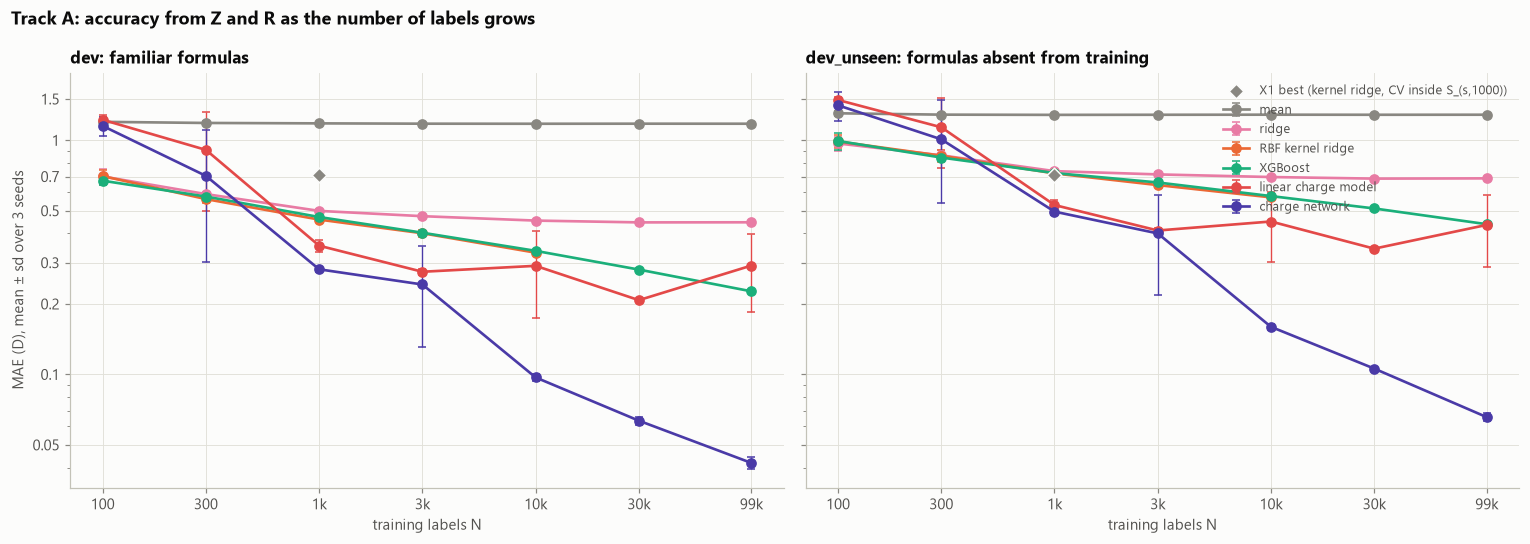

n_train,100,300,1000,3000,10000,30000,99198
model,,,,,,,
mean,1.198 ± 0.058,1.185 ± 0.025,1.181 ± 0.013,1.177 ± 0.000,1.176 ± 0.001,1.177 ± 0.000,1.176 ± 0.000
ridge,0.700 ± 0.053,0.589 ± 0.014,0.499 ± 0.010,0.474 ± 0.001,0.454 ± 0.005,0.446 ± 0.001,0.446 ± 0.000
RBF kernel ridge,0.703 ± 0.044,0.561 ± 0.019,0.458 ± 0.006,0.401 ± 0.013,0.331 ± 0.004,nan,nan
XGBoost,0.672 ± 0.029,0.575 ± 0.009,0.470 ± 0.006,0.403 ± 0.007,0.337 ± 0.003,0.280 ± 0.004,0.226 ± 0.001
linear charge model,1.223 ± 0.055,0.909 ± 0.411,0.355 ± 0.022,0.274 ± 0.008,0.291 ± 0.117,0.208 ± 0.001,0.292 ± 0.106
charge network,1.151 ± 0.111,0.704 ± 0.401,0.281 ± 0.007,0.242 ± 0.111,0.097 ± 0.003,0.063 ± 0.002,0.042 ± 0.002


n_train,100,300,1000,3000,10000,30000,99198
model,,,,,,,
mean,1.304 ± 0.033,1.286 ± 0.022,1.283 ± 0.012,1.285 ± 0.000,1.286 ± 0.001,1.285 ± 0.000,1.285 ± 0.000
ridge,0.969 ± 0.068,0.862 ± 0.045,0.738 ± 0.008,0.715 ± 0.014,0.696 ± 0.001,0.686 ± 0.003,0.687 ± 0.000
RBF kernel ridge,0.988 ± 0.060,0.859 ± 0.050,0.722 ± 0.002,0.644 ± 0.013,0.570 ± 0.006,nan,nan
XGBoost,0.993 ± 0.083,0.844 ± 0.029,0.724 ± 0.016,0.660 ± 0.010,0.577 ± 0.008,0.511 ± 0.002,0.438 ± 0.007
linear charge model,1.486 ± 0.037,1.136 ± 0.372,0.529 ± 0.026,0.412 ± 0.012,0.450 ± 0.149,0.344 ± 0.004,0.435 ± 0.148
charge network,1.410 ± 0.205,1.009 ± 0.472,0.496 ± 0.018,0.400 ± 0.182,0.160 ± 0.004,0.106 ± 0.002,0.066 ± 0.002


In [5]:
MODELS_A = ["mean", "ridge", "rbf_krr", "xgb", "charge_linear", "charge_net"]
summ_a = track_a.groupby(["eval_set", "model", "n_train"])["mae_D"].agg(["mean", "std"]).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, ev in zip(axes, EVAL):
    for m in MODELS_A:
        s = summ_a[(summ_a["eval_set"] == ev) & (summ_a["model"] == m)].sort_values("n_train")
        ax.errorbar(s["n_train"], s["mean"], yerr=s["std"], color=COLORS[m], marker="o", capsize=2.5, elinewidth=0.9,
                    label=LABELS[m])
    ax.scatter([1000], [0.713], marker="D", s=46, color=MUTED, zorder=3, edgecolors=SURFACE, linewidths=1,
               label="X1 best (kernel ridge, CV inside S_(s,1000))")
    ax.set(xscale="log", yscale="log", xlabel="training labels N",
           title=f"{ev}: {'familiar formulas' if ev == 'dev' else 'formulas absent from training'}")
    ax.xaxis.set_major_locator(FixedLocator(SIZES))
    ax.xaxis.set_major_formatter(lambda v, _: f"{v / 1000:.0f}k" if v >= 1000 else f"{v:.0f}")
    ax.xaxis.set_minor_locator(NullLocator())
    ticks = [0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5]
    ax.yaxis.set_major_locator(FixedLocator(ticks))
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:g}")
    ax.yaxis.set_minor_formatter(NullFormatter())
axes[0].set_ylabel("MAE (D), mean ± sd over 3 seeds")
axes[1].legend(loc="upper right", fontsize=8.5)
fig.suptitle("Track A: accuracy from Z and R as the number of labels grows", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "explore04_learning_curves.png")
plt.show()

def pm(frame):
    return frame["mean"].map("{:.3f}".format) + " ± " + frame["std"].map("{:.3f}".format)

for ev in EVAL:
    t = summ_a[summ_a["eval_set"] == ev].assign(value=lambda d: pm(d), model=lambda d: d["model"].map(LABELS))
    display(t.pivot(index="model", columns="n_train", values="value").loc[[LABELS[m] for m in MODELS_A]]
            .style.set_caption(f"Track A, {ev}: MAE (D), mean ± sd over 3 seeds"))

In [6]:
full = track_a[track_a["n_train"] == FULL].groupby(["eval_set", "model"])[["mae_D", "rmse_D", "rmse_below_tail_D", "r2", "bias_D"]].mean()
full = full.reset_index().assign(model=lambda d: d["model"].map(LABELS)).set_index(["eval_set", "model"])
display(full.style.format("{:.3f}").set_caption(f"Track A at the full pool (N = {FULL:,}), mean over 3 seeds"))

slopes = (summ_a[summ_a["n_train"] >= 1000].groupby(["eval_set", "model"])[["n_train", "mean"]]
          .apply(lambda s: loglog_slope(s["n_train"].to_numpy(), s["mean"].to_numpy())).unstack("eval_set"))
slopes.index = slopes.index.map(LABELS)
display(slopes.style.format("{:+.2f}").set_caption("learning-curve slope d log(MAE) / d log(N), N ≥ 1000"))

eval_set,dev,dev_unseen
model,,
linear charge model,-0.06,-0.05
charge network,-0.45,-0.47
mean,-0.00,+0.00
RBF kernel ridge,-0.14,-0.10
ridge,-0.02,-0.02
XGBoost,-0.16,-0.11


## 3. Track B: the quantum-comparable baselines

The brief's models (mean, RBF kernel ridge, random forest) plus ridge and XGBoost (X1's grids; kernel ridge with
the dimension-scaled bandwidth grid), at N = 100, 300 and 1000, on three inputs: **all_legal** (188 features), the
**reduced** inputs chosen in notebook 03 (the same numbers a k-qubit angle encoding would see), and **composition**
only (the brief's ablation). Hyperparameters by 5-fold CV inside each S_(s,N). Reported: that CV MAE (the protocol a
quantum kernel model can follow at the same cost) and the development-set scores. A matched-k table gives RBF kernel
ridge on the chosen reduction at several k, so M4 has a matched baseline whatever number of qubits it uses.

In [7]:
TRACK_B = {s: {n: by_n[n] for n in splits.track_b_sizes} for s, by_n in splits.train.items()}
RED_NAME = f"{RED[0]}{RED[1]}"
VARIANTS = {"all_legal": (SETS["all_legal"], None), RED_NAME: (SETS["all_legal"], RED), "composition": (SETS["composition"], None)}

def make_track_b(seed, n):
    out = {"mean": MeanFitter()}
    for vname, (cols, reduction) in VARIANTS.items():
        X = features[cols]
        for m in TBC["models"]:
            if m == "mean":
                continue
            est, grid = classical.build(m, seed, scaling=SC_B, target=TG_B, reduction=reduction, n_features=len(cols))
            out[f"{m}|{vname}"] = TabularFitter(X, est, grid, seed, cv_max_n=max(splits.track_b_sizes))
    for k in TBC["matched_k"]:
        if (RED[0], k) != RED:
            est, grid = classical.build("rbf_krr", seed, scaling=SC_B, target=TG_B, reduction=(RED[0], k))
            out[f"rbf_krr|{RED[0]}{k}"] = TabularFitter(XA, est, grid, seed, cv_max_n=max(splits.track_b_sizes))
    return out

start = time.perf_counter()
track_b, preds_b = dev_curve(make_track_b, TRACK_B, EVAL, y, cache_dir=CACHE, progress=False)
track_b[["model", "features"]] = track_b["model"].str.split("|", expand=True).reindex(columns=[0, 1])
track_b["features"] = track_b["features"].fillna("—")
track_b["cv_mae_D"] = track_b["details"].map(lambda d: json.loads(d).get("tuning_mae_D", np.nan))
track_b["track"] = "B"
print(f"Track B: {track_b[['seed', 'n_train', 'model', 'features']].drop_duplicates().shape[0]} fits in "
      f"{(time.perf_counter() - start) / 60:.0f} min")
_ = save_result(track_b, "explore04_track_b", scaling=SC_B, target=TG_B, reduction=list(RED),
                label="exploratory; Z, R only; Track B (N <= 1000); 5-fold CV inside S_(s,N); scored on dev and dev_unseen")

Track B: 162 fits in 42 min


In [8]:
dev_b = track_b[track_b["eval_set"] == "dev"]
tab = dev_b.groupby(["features", "model", "n_train"])[["cv_mae_D", "mae_D"]].mean().unstack("n_train")
tab.columns = [f"{'CV' if c == 'cv_mae_D' else 'dev'} MAE, N={n}" for c, n in tab.columns]
order = [c for metric in ("CV", "dev") for c in tab.columns if c.startswith(metric)]
tab = tab[order].reset_index()
tab = tab[tab["features"].isin(["—", *VARIANTS])].assign(model=lambda d: d["model"].map(LABELS)).set_index(["features", "model"])
display(tab.style.format("{:.3f}").set_caption("Track B: mean over 3 seeds (D). CV: 5-fold inside S_(s,N); dev: development set"))

matched = dev_b[(dev_b["model"] == "rbf_krr") & dev_b["features"].str.startswith(RED[0])].copy()
matched["k"] = matched["features"].str.removeprefix(RED[0]).astype(int)
mk = matched.groupby(["k", "n_train"])[["cv_mae_D", "mae_D"]].mean().unstack("n_train")
mk.columns = [f"{'CV' if c == 'cv_mae_D' else 'dev'} MAE, N={n}" for c, n in mk.columns]
display(mk.style.format("{:.3f}").set_caption(f"Matched-k baselines: RBF kernel ridge on k {RED[0].upper()} inputs (mean over seeds, D)"))

,"CV MAE, N=100","CV MAE, N=300","CV MAE, N=1000","dev MAE, N=100","dev MAE, N=300","dev MAE, N=1000"
k,,,,,,
4,0.709,0.604,0.574,0.694,0.610,0.569
6,0.723,0.578,0.524,0.694,0.591,0.519
8,0.742,0.574,0.500,0.715,0.589,0.507
10,0.755,0.590,0.498,0.738,0.582,0.497
12,0.780,0.597,0.496,0.744,0.591,0.494
16,0.815,0.595,0.492,0.789,0.597,0.486


## 4. The baselines a quantum model must be reported against

For each Track B size: the **best Track A model** (any legal input, any model family, from section 2) and the
**matched Track B model** (RBF kernel ridge on the same k reduced inputs a k-qubit model would use), both on the
development set, with the composition-only and mean baselines for scale. A quantum kernel model in M4 is reported
against both columns. Beating only the matched column says the quantum kernel is a better similarity measure on
those inputs; it does not say anyone should use it.

In [9]:
dev_a = track_a[track_a["eval_set"] == "dev"]
rows = []
for n in splits.track_b_sizes:
    a = dev_a[dev_a["n_train"] == n].groupby("model")["mae_D"].agg(["mean", "std"])
    best_a = a.drop(index="mean")["mean"].idxmin()
    b = dev_b[dev_b["n_train"] == n].groupby(["model", "features"])[["mae_D", "cv_mae_D"]].agg(["mean", "std"])
    m = b.loc[("rbf_krr", RED_NAME)]
    comp = b.xs("composition", level="features")[("mae_D", "mean")]
    rows.append({"N": n, "best Track A model": LABELS[best_a],
                 "best Track A dev MAE": f"{a.loc[best_a, 'mean']:.3f} ± {a.loc[best_a, 'std']:.3f}",
                 f"matched ({RED_NAME}, RBF KRR) dev MAE": f"{m[('mae_D', 'mean')]:.3f} ± {m[('mae_D', 'std')]:.3f}",
                 f"matched CV MAE": f"{m[('cv_mae_D', 'mean')]:.3f} ± {m[('cv_mae_D', 'std')]:.3f}",
                 "best composition-only dev MAE": f"{comp.min():.3f}", "mean baseline dev MAE": f"{a.loc['mean', 'mean']:.3f}"})
baselines = pd.DataFrame(rows).set_index("N")
display(baselines.style.set_caption("Baselines for the quantum model (development set; mean ± sd over 3 seeds)"))
_ = save_result(baselines.reset_index(), "explore04_quantum_baselines", reduction=list(RED),
                label="exploratory; Z, R only; development-set baselines for M4")

,best Track A model,best Track A dev MAE,"matched (pls10, RBF KRR) dev MAE",matched CV MAE,best composition-only dev MAE,mean baseline dev MAE
N,,,,,,
100,XGBoost,0.672 ± 0.029,0.738 ± 0.069,0.755 ± 0.115,1.025,1.198
300,RBF kernel ridge,0.561 ± 0.019,0.582 ± 0.013,0.590 ± 0.087,1.016,1.185
1000,charge network,0.281 ± 0.007,0.497 ± 0.006,0.498 ± 0.022,0.986,1.181


## 5. Effective number of parameters

How much flexibility each fitted model uses (ESL §7.6; `src/qm9dipole/complexity.py`): exact df = tr(S) for ridge and
kernel ridge on unsupervised inputs (the same formula will apply to the quantum kernel in M4), Ye's Monte-Carlo
estimate for trees and for models whose inputs were chosen with y (PLS, top-k), measured in the transformed-target
space. Track B at every (seed, N); Track A for ridge at every N and kernel ridge up to 10,000. The charge models are
not linear smoothers and too costly to refit 20 times at large N; their raw parameter counts are listed instead.

In [10]:
from qm9dipole.complexity import effective_df

rng = np.random.default_rng(2026)
df_rows = []
start = time.perf_counter()
for r in dev_b.drop_duplicates(["seed", "n_train", "model", "features"]).itertuples():
    if r.model == "mean" or r.features not in ("all_legal", RED_NAME):
        continue
    cols, reduction = VARIANTS[r.features]
    ids = splits.train[r.seed][r.n_train]
    est = classical.build(r.model, r.seed, scaling=SC_B, target=TG_B, reduction=reduction,
                          n_features=len(cols))[0].set_params(**json.loads(r.details)["params"])
    dfv, se, method = effective_df(est, features.loc[ids, cols].to_numpy(), y.loc[ids].to_numpy(), rng, n_rep=20)
    df_rows.append({"track": "B", "seed": r.seed, "n_train": r.n_train, "model": r.model, "features": r.features,
                    "df": dfv, "df_se": se, "method": method})
for r in dev_a.drop_duplicates(["seed", "n_train", "model"]).itertuples():
    if r.model not in ("ridge", "rbf_krr"):
        continue
    ids = splits.train[r.seed][r.n_train]
    est = classical.build(r.model, r.seed, scaling=SC_A, target=TG_A, n_features=XA.shape[1])[0]
    est.set_params(**json.loads(r.details)["params"])
    dfv, se, method = effective_df(est, XA.loc[ids].to_numpy(), y.loc[ids].to_numpy(), rng, n_rep=20)
    df_rows.append({"track": "A", "seed": r.seed, "n_train": r.n_train, "model": r.model, "features": "all_legal",
                    "df": dfv, "df_se": se, "method": method})
dof = pd.DataFrame(df_rows)
_ = save_result(dof, "explore04_effective_df", n_rep=20, label="exploratory; df of models refit on S_(s,N)")
print(f"effective df for {len(dof)} fitted models in {(time.perf_counter() - start) / 60:.1f} min")
tab = dof.groupby(["track", "features", "model", "n_train"])["df"].mean().unstack("n_train")
display(tab.style.format("{:.1f}", na_rep="").set_caption("effective number of parameters df (mean over seeds)"))
params = {m: json.loads(dev_a[dev_a["model"] == m]["details"].iloc[0])["n_parameters"] for m in ("charge_linear", "charge_net")}
print("trainable parameters: " + ", ".join(f"{LABELS[m]} {v:,}" for m, v in params.items()))

effective df for 108 fitted models in 39.9 min


trainable parameters: linear charge model 520, charge network 118,346


In [11]:
# Development-set predictions for notebook 05 (gitignored; regenerated with the cache).
rows = []
for (seed, n, model), by_set in {**preds_a, **{(s, n, m): p for (s, n, m), p in preds_b.items()}}.items():
    for ev, p in by_set.items():
        rows.append(pd.DataFrame({"id": p.index, "pred_D": p.to_numpy(), "seed": seed, "n_train": n, "model": model,
                                  "eval_set": ev, "track": "A" if (seed, n, model) in preds_a else "B"}))
pd.concat(rows, ignore_index=True).to_parquet(PROCESSED_DIR / "explore04_dev_predictions.parquet")
print("saved development-set predictions for notebook 05")

saved development-set predictions for notebook 05


## Summary

1. **The latent-charge network wins the architecture search by a wide margin.** On the inner validation split of
   S_(0,10000), three message-passing rounds with bond-directed atomic dipoles (`mp3`, 118,346 parameters) reach
   0.092 D (dev 0.094 D), against 0.505 D for a linear charge model, 0.228 D with atomic dipoles added and 0.116 D for
   an MLP without message passing. Atomic dipoles matter (two rounds: 0.191 D with them, 0.217 D without). The chosen
   linear model is `linear+dipoles`.
2. **Track A: the charge network is the most accurate model from Z and R by far, from N = 1000 on.** Development MAE
   0.281 D at N = 1,000, 0.097 D at 10,000 and **0.042 D on the full pool** (RMSE 0.079 D, R² 0.997); on formulas
   absent from training 0.496, 0.160 and **0.066 D** (R² 0.990). Its learning curve keeps falling (slope −0.45 for
   N ≥ 1000) while XGBoost (−0.16), RBF kernel ridge (−0.14) and ridge (−0.02) flatten: they are limited by the
   molecule-level features, the network is not.
3. **Below N = 1000 the network is unreliable**: 1.151 ± 0.111 D at N = 100 (no better than the mean, 1.198 D) and
   0.704 ± 0.401 D at N = 300, where one seed failed (1.167 D). The best Track A models there are XGBoost (0.672 D at
   N = 100) and RBF kernel ridge (0.561 D at N = 300). The linear charge model is unstable across seeds at several
   sizes (sd 0.41 D at N = 300, 0.12 D at 10,000, 0.11 D at the full pool).
4. **The scaling guard was necessary.** With z-scores clipped at ±10 (DECISIONS.md, 2026-10-07), Track A ridge
   behaves (0.700 D at N = 100 to 0.446 D on the full pool). In the first, unguarded run of this notebook its mean
   development MAE was 17,899 D at N = 100 and 25,669 D at N = 300.
5. **Track B (N ≤ 1000, quantum-comparable).** The best model at every size, chosen by CV, is RBF kernel ridge
   (on 4 PLS inputs at N = 100, on all 188 features at N = 300 and 1000): dev MAE 0.694, 0.554 and 0.463 D. Reducing to
   the 10 PLS inputs a 10-qubit model can take costs 0.03–0.04 D at every size (RBF kernel ridge on PLS(10):
   0.738, 0.582 and 0.497 D).
   **Composition alone** (the brief's ablation) is barely better than the mean: 0.986 D at N = 1000 against 1.181 D;
   isomers share a formula but not a dipole.
6. **Matched-k baselines** (RBF kernel ridge on k PLS inputs, dev MAE at N = 1000): 0.569 (k = 4), 0.519 (6),
   0.507 (8), 0.497 (10), 0.494 (12), 0.486 D (16). More inputs help at N = 1000, but at N = 100 the fewest are best
   (0.694 D at k = 4, 0.789 D at k = 16): supervised directions fit on 80 molecules are noisy.
7. **Effective number of parameters.** Track A ridge saturates at the feature count (df 187.8 of 188 at the full pool);
   RBF kernel ridge grows with the data (42 at N = 100, 2,884 at N = 10,000). At N = 1000 in Track B: ridge 101,
   RBF kernel ridge 403 on all features and 125 on PLS(10), random forest 627, XGBoost 859 (Monte-Carlo estimates
   for the trees and for PLS pipelines). The charge network has 118,346 trainable parameters.

**Carried forward:** the baselines every quantum model is reported against (notebook 06), at N = 100 / 300 / 1000 on
`dev`: matched RBF kernel ridge on PLS(10) 0.738 / 0.582 / 0.497 D; best Track B 0.694 / 0.554 / 0.463 D; best
Track A 0.672 / 0.561 / 0.281 D; and 0.042 D with all 99,198 labels. Notebook 05 reads this run's development-set
predictions. Runtime of this re-run: Track A 18 min (its expensive fits came from the first run's cache), Track B
42 min, effective df 40 min.